In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
data = pd.read_csv(r'../Data/dataset/spy_1min_2008_2021_cleaned.csv', parse_dates=['date'], index_col='date')

In [17]:
# Intraday Variance
close_5mn = data.close.resample("5min").last().dropna()
rt_intraday = np.log(close_5mn / close_5mn.shift(1)).dropna()
rv_intraday = (rt_intraday ** 2).groupby(rt_intraday.index.date).sum()

# Overnight Variance
daily_ohlc = data.close.resample("1D").agg(['first', 'last']).dropna()
daily_ohlc["prev_close"] = daily_ohlc['last'].shift(1)

# Overnight returns
rt_overnight = np.log(daily_ohlc['first'] / daily_ohlc['prev_close']).dropna()
rv_overnight = rt_overnight ** 2

# Total Realized Variance
rv_total = pd.DataFrame({'intraday': rv_intraday, 'overnight': rv_overnight}).dropna()
rv_total['RV_Daily_Var'] = rv_total['intraday'] + rv_total['overnight']

# Scale to match GARCH (x100^2 = x10000)
target_variance = rv_total['RV_Daily_Var'] * 10000
target_volatility = np.sqrt(target_variance)


target_volatility.head()

2008-01-23    4.384125
2008-01-24    1.830364
2008-01-25    2.293130
2008-01-28    1.539837
2008-01-29    1.356504
Name: RV_Daily_Var, dtype: float64

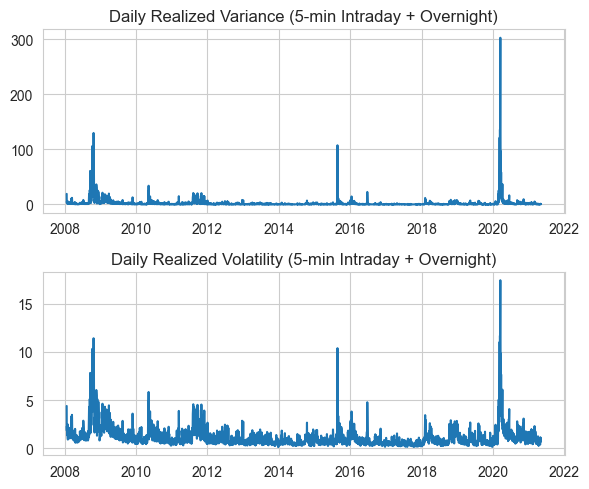

In [20]:
fig, ax = plt.subplots(2, 1, figsize=(6,5),)

target_variance.plot(title="Daily Realized Variance (5-min Intraday + Overnight)", ax=ax[0])
target_volatility.plot(title="Daily Realized Volatility (5-min Intraday + Overnight)", ax=ax[1])
plt.tight_layout()
plt.show()